<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/Final-Project/Project_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
!pip install gensim
!pip install pyldavis
!pip install nltk

I used the Gensim library to create my topic model, and the NLTK to get a list of stop words.

In [53]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

I downloaded the list of English stopwords.

In [54]:
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

I downloaded everything else once I got my libraries installed.

In [55]:
import requests
import io

url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/Final-Project/ufo_sightings.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

I used the "UFO Sightings around the world" dataset from the Curated Datasets in the TidyTuesday Project.

In [56]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

          date_time             city_area state country ufo_shape  \
0  10/10/1949 20:30            san marcos    tx      us  cylinder   
1  10/10/1949 21:00          lackland afb    tx     NaN     light   
2  10/10/1955 17:00  chester (uk/england)   NaN      gb    circle   
3  10/10/1956 21:00                  edna    tx      us    circle   
4  10/10/1960 20:00               kaneohe    hi      us     light   

   encounter_length described_encounter_length  \
0            2700.0                 45 minutes   
1            7200.0                    1-2 hrs   
2              20.0                 20 seconds   
3              20.0                   1/2 hour   
4             900.0                 15 minutes   

                                         description date_documented  \
0  This event took place in early fall around 194...       4/27/2004   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...      12/16/2005   
2  Green/Orange circular disc over Chester&#44 En...       1/21/2008

I saved the dataset as a dataframe With the dr variable holding pandas DataFrame.

In [57]:
df = df[["date_time", "country", "description"]]
df

,date_time,country,description
0,10/10/1949 20:30,us,This event took place in early fall around 194...
1,10/10/1949 21:00,NaN,1949 Lackland AFB&#44 TX. Lights racing acros...
2,10/10/1955 17:00,gb,Green/Orange circular disc over Chester&#44 En...
3,10/10/1956 21:00,us,My older brother and twin sister were leaving ...
4,10/10/1960 20:00,us,AS a Marine 1st Lt. flying an FJ4B fighter/att...
...,...,...,...
80327,9/9/2013 21:15,us,Round from the distance/slowly changing colors...
80328,9/9/2013 22:00,us,Boise&#44 ID&#44 spherical&#44 20 min&#44 10 r...
80329,9/9/2013 22:00,us,Napa UFO&#44
80330,9/9/2013 22:20,us,Saw a five gold lit cicular craft moving fastl...


The pandas DataFrame! I am examining the physical traits of the UFOs from the witness reports. These traits can be used by government officals for further analysis to determine if the "UFOs" are a serious threat to national security.

In [58]:
docs = df.description.tolist()
print(docs[0])

This event took place in early fall around 1949-50. It occurred after a Boy Scout meeting in the Baptist Church. The Baptist Church sit


All documents were placed into a list to model all the descriptions of UFO Sightings from our dataset.

In [59]:
stop_words = stopwords.words('english')

I added some stopwords from the English stopword list.

In [60]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    return final_words

To clean the documents, a single document is treated as an input, and returned as a clean sequence of words with no punctuation or stop words.

In [61]:
custom_stopwords = ['thought', 'like', 'sky', 'saw', 'looked']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['thought', 'like', 'sky', 'saw', 'looked']


I added some custom stopwords that would have most likely popped up throughout the analysis. Things like 'sky' or 'saw' offere very little to no insights about the appearance of the UFOs.

In [62]:
cleaned_docs = [clean_doc(str(doc)) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(str(docs[0]))
print("\nOriginal document (first one):")
print(str(docs[0]))
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
This event took place in early fall around 1949-50. It occurred after a Boy Scout meeting in the Baptist Church. The Baptist Church sit

Cleaned document with custom stopwords:
['event', 'took', 'place', 'early', 'fall', 'around', '194950', 'occurred', 'boy', 'scout', 'meeting', 'baptist', 'church', 'baptist', 'church', 'sit']


The cleaning process, ID-Word Index, and Corpus now have the new stopwords.

In [63]:
cleaned_docs = [clean_doc(str(doc)) for doc in docs]

All documents were processed again. The documents were converted into a 'cleaned_docs' list. This is our representation of our sequence of words.

In [64]:
id2word = corpora.Dictionary(cleaned_docs)

With a ID-Word Index, I converted all words into numbers for the LDA topic model to work.

In [65]:
id2word[250]

'happened'

I queried the ID-Word Index, and examined what word maps to index number 250. I got 'happened'.

This could imply that most of the witnesses in the reports of UFO Sightings genuinely believe that the events they described were most likely real. Even if they might not fully believe that it was real, they might feel like it would be careless to completely dismiss a potential threat to aviation and national safety.

In [66]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

With the 'doc2bow()' method, I converted all the documents into a squence of numbers instead of words.

In [67]:
print(corpus[0])

[(0, 1), (1, 1), (2, 2), (3, 1), (4, 2), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1)]


My corpus object is now a bag-of-words. This data will be used for my LDA model.

In [68]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	194950
1	around
2	baptist
3	boy
4	church
5	early
6	event
7	fall
8	meeting
9	occurred
10	place
11	scout
12	sit
13	took


I mapped each number to the ID-Word Index to see what the numbers from above correspond to.

In [69]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=100)

WIth my 'corpus' object, 'id2word' index, and 'num_topics' (number of topics), I went ahead and trained my LDA model. I decided to go over 100 topics to get as much coverage as possible for my sample.

In [70]:
topics = lda_model.get_document_topics(corpus)
len(topics)

80332

I used the 'get_document_topics()' to get the topics for each corpus.

In [71]:
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(8, 0.07215005159378052)
(27, 0.07214735448360443)
(34, 0.07214909791946411)
(40, 0.07214824110269547)
(61, 0.07207183539867401)
(74, 0.5721821188926697)


These topics were then assigned to the document in the cell below.

In [72]:
print(docs[0])

This event took place in early fall around 1949-50. It occurred after a Boy Scout meeting in the Baptist Church. The Baptist Church sit


In [73]:
for topic in topics[0][:3]:
    terms = lda_model.get_topic_terms(topic[0], 10)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(8, 0.07215006649494171)
446 blue
1 around
149 light
84 bright
230 white
172 turning
22 lights
190 moving
226 large
199 l

(27, 0.07214736938476562)
465 suddenly
2138 northeast
932 view
1346 less
10 place
3031 remained
3686 1100
714 ground44
3396 heads
3498 gradually

(34, 0.0721491128206253)
323 sound
13 took
1009 unknown
2277 distant
22 lights
34 brother
1517 main
2627 quotvquot
242 window
1385 another44



I printed the top 10 words with the 'get_topic()' method to print some key words for each of the top 3 topics.

In [74]:
topic_data = []
target_topic_ids = [2, 5, 10, 15]

for topic_id in target_topic_ids:

    topic_terms = lda_model.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID       Word  Probability
0         2  formation     0.287029
1         2   triangle     0.254690
2         2     lights     0.194244
3         2         ft     0.048658
4         2      amber     0.047524


I went ahead and created a facet bar graph  for topics 2, 5, 10, and 15, to visualize the top 10 words and their probabilities for each topic. In this cell, I converted he topic words and probabilities into a pandas DataFrame.

I am hoping that these word topics cover enough descriptions over the physical traits of the UFOs.

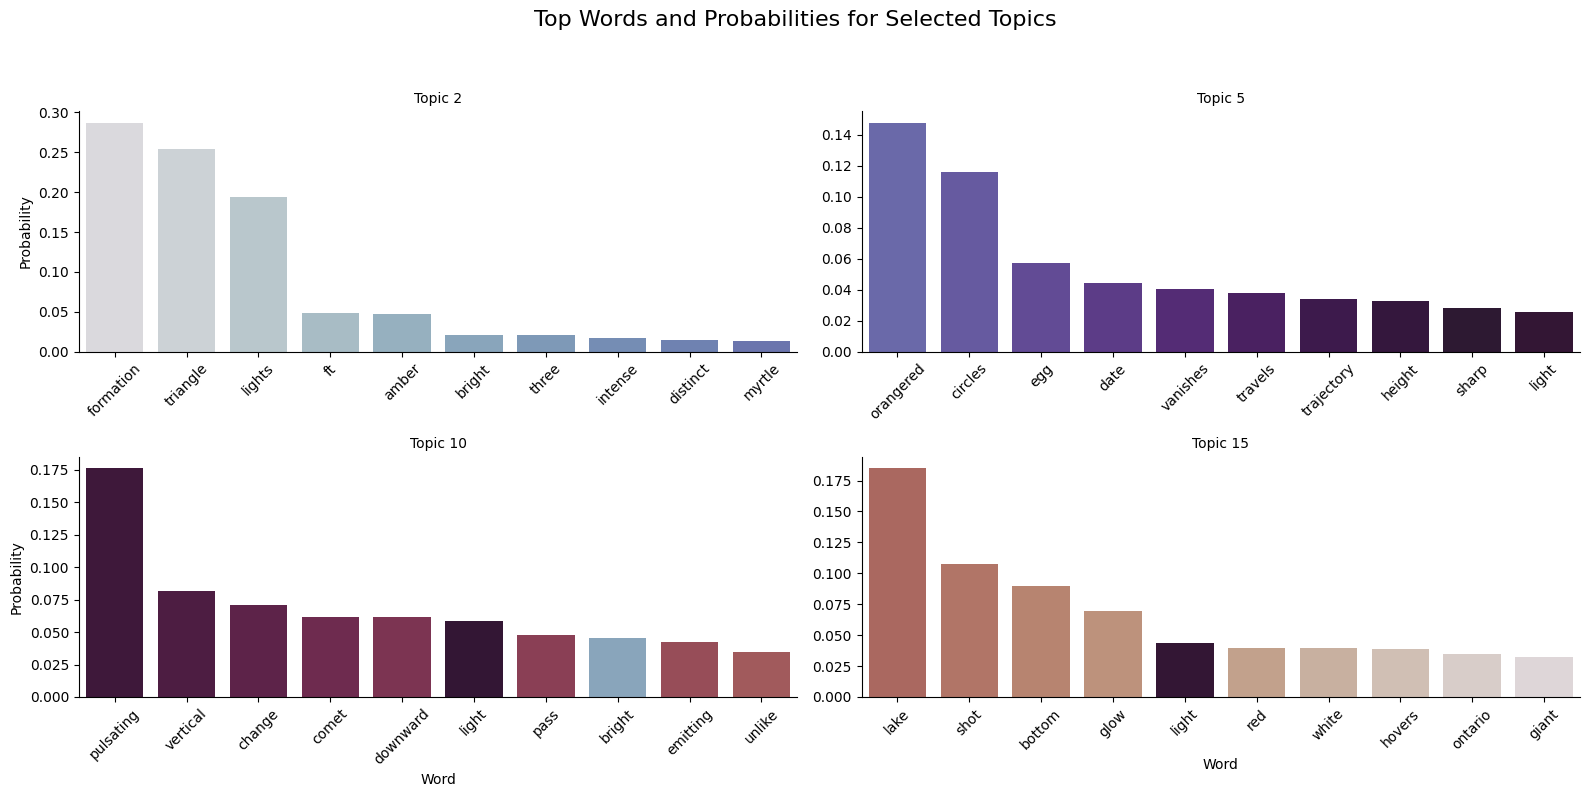

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


With the 'seaborn.catplot', I created a facet bar graph to visualize the top 10 words and their probabilities for each of the target topics (2, 5, 10, and 15).

Based on this visual, the topics are divided by different descriptive words for a UFO's appearence. Topic 2 seems to focus on the UFOs' overall shape.

Topic 5 seems to focus more on some physical traits, such as "circies," "egg," and "sharp". But this could be describing the movements of the UFOs, since "vanishes" and "travels" is here. "circles" could be a UFO going in circles for some reason.

Topic 10 seems to be more explicitly about the UFOs movement.

Topic 15 appears to describe where the UFO was spotted at.

In [76]:
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word, mds="mmds", R=30)

In [77]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
96    -0.227331 -0.008209       1        1  2.440653
61     0.230309 -0.348853       2        1  2.357893
31     0.121442 -0.060303       3        1  2.239333
73    -0.381710 -0.368506       4        1  2.236602
69     0.285542 -0.243909       5        1  2.205538
...         ...       ...     ...      ...       ...
41     0.156482 -0.422497      96        1  0.513914
90     0.077439 -0.209478      97        1  0.482208
12     0.071842  0.004432      98        1  0.480295
28    -0.087529 -0.409069      99        1  0.466619
48    -0.037917  0.042014     100        1  0.418047

[100 rows x 5 columns], topic_info=       Term         Freq         Total  Category  logprob  loglift
91   orange  7885.000000   7885.000000   Default  30.0000  30.0000
173     ufo  5231.000000   5231.000000   Default  29.0000  29.0000
152  shaped  6340.000000   6340.000000   Default  28.0000  28.0000
51   flying  5462.000000   5462.000000   Default  27.0000  27.0000
187     two  5368.000000   5368.000000   Default  26.0000  26.0000
..      ...          ...           ...       ...      ...      ...
149   light   209.575232  18544.337338  Topic100  -2.6611   0.9945
226   large    49.453404   4541.216887  Topic100  -4.1052   0.9574
22   lights    84.389189  18457.168110  Topic100  -3.5708   0.0896
230   white    35.459917   8406.662133  Topic100  -4.4378   0.0090
103  object    11.747601  15481.765441  Topic100  -5.5426  -1.7064

[3759 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
176      32  0.998287        1
680      55  0.999049       10
1653     63  0.997840      100
1709     20  0.993638     1000
2618     69  0.929939   1000ft
...     ...       ...      ...
3434     94  0.956573  zigzags
4568      3  0.974855   zipped
3983     45  0.923343  zipping
4222     29  0.964383     zoom
1208     66  0.991022   zoomed

[2950 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[97, 62, 32, 74, 70, 46, 81, 99, 21, 55, 48, 3, 71, 9, 45, 66, 43, 82, 31, 92, 73, 87, 52, 40, 25, 5, 54, 56, 76, 41, 47, 83, 96, 77, 65, 90, 50, 78, 98, 19, 33, 34, 88, 100, 24, 2, 89, 23, 15, 12, 16, 85, 26, 94, 93, 72, 17, 4, 61, 38, 53, 58, 37, 68, 84, 51, 8, 44, 60, 14, 36, 18, 86, 7, 67, 35, 57, 1, 10, 95, 39, 69, 59, 64, 80, 79, 22, 30, 27, 75, 11, 63, 28, 6, 20, 42, 91, 13, 29, 49])

WIth the PyLDAVis library, I can see all 100 topics plotted in a two-dimensional space. As well as the degree to which the words in each topic are unique to that topic compared to the corpus as a whole.

It appears that the "UFOs" are mainly associated with "lights" and "light". Since people are reporting lights, most of these events seem to take place at night. Extraterrestrial life or not, the recurring events at night could imply that this security threat knows that night time is the perfect time to sneak around without being detected by a large amount of people.